# Pushover Analysis on MDOF Stick Model

## Introduction

This Jupyter Notebook outlines a structured workflow for conducting pushover analysis on multi-degree-of-freedom (MDOF) structural models using OpenSees. Pushover analysis is a static, nonlinear procedure that helps assess the inelastic behavior and capacity of structures under increasing lateral loads, simulating the effects of seismic demand in a simplified manner.

The analysis focuses on building models representative of typical structures located in seismic-prone regions, such as L'Aquila, and explores their performance through monotonic and cyclic pushover procedures. Unlike time-history analysis, which uses dynamic input, pushover analysis incrementally applies lateral forces or displacements to assess structural response and identify limit states.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDoF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including: mass, height, fundamental period, and the nonlinear behavior at each degree of freedom, including plastic hinges or other inelastic mechanisms

3. **Run Static (Monotonic) Pushover Analysis in OpenSees**: Apply a monotonically increasing lateral load (typically using a predefined force or displacement pattern such as inverted triangular or uniform) until structural collapse or a target displacement is reached. Extract key response metrics such as base shear vs. roof displacement/maximum interstorey drift curves (capacity curves)

4. **Run Cyclic Pushover Analysis in OpenSees**: Apply cyclic loading protocols to assess structural degradation, stiffness deterioration, and strength loss under repeated loading. This allows for evaluation of energy dissipation capacity, hysteretic response, etc.

---

## References

[1] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi:10.1177/8755293019891724

## Initialize Libraries ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.units         import units              # oq-vtmk units class
from openquake.vmtk.calibration   import calibrate_model    # oq-vmtk sdof-to-mdof calibration class
from openquake.vmtk.modeller      import modeller           # oq-vmtk numerical modelling class
from openquake.vmtk.plotter       import plotter            # oq-vmtk plotting class

## Define Plotting Constants for OQ-VMTK Non-Native Plots ##

In [2]:
FONTSIZE_1 = 16
FONTSIZE_2 = 14
FONTSIZE_3 = 12

LINEWIDTH_1= 3
LINEWIDTH_2= 2
LINEWIDTH_3 = 1

RESOLUTION = 500

MARKER_SIZE_1 = 100
MARKER_SIZE_2 = 60
MARKER_SIZE_3 = 10

COLOR = "#399283"

## Calibrate and Compile the Stick Model ##

Below is a list of required input parameters associated with the single-degree-of-freedom oscillator if an SDOF-to-MDOF calibration is required.

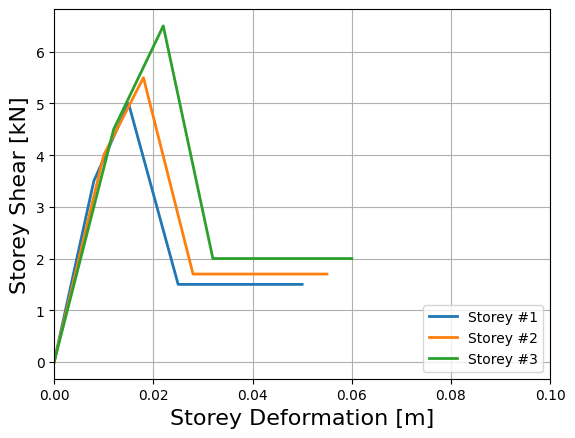

In [3]:
# Number of storeys
number_storeys = 3 

# Relative floor heights list
floor_heights = [2.80, 3.00, 3.00]

# Relative floor masses list
floor_masses = [0.75, 0.75, 0.75] # Unit mass for SDOFs

# MDOF capacity (First row are Spectral Displacement [m] values - Second row are Spectral Acceleration [g] values)
# 3 storeys × 4 points each
storey_disps = np.array([
    [0.008, 0.015, 0.025, 0.050],   # storey 1: Brittle failure at ~1.5% drift
    [0.010, 0.018, 0.028, 0.055],   # storey 2
    [0.012, 0.022, 0.032, 0.060]    # storey 3
]) * units.m

storey_forces = np.array([
    [3.5, 5.0, 1.5, 1.5],  # storey 1: Sharp drop from 10kN to 3kN
    [4.0, 5.5, 1.7, 1.7],  # storey 2
    [4.5, 6.5, 2.0, 2.0]   # storey 3
]) * units.kN

# Flag to activate default stiffness-strength degradation and pinching4
mdof_degradation = True

# Plot the capacities to visualise the outcome of the calibration
for i in range(storey_disps.shape[0]):
   plt.plot(np.concatenate(([0.0], storey_disps[i,:])), np.concatenate(([0.0], storey_forces[i,:])), lw=LINEWIDTH_2, label = f'Storey #{i+1}')
plt.xlabel('Storey Deformation [m]', fontsize= FONTSIZE_1)
plt.ylabel('Storey Shear [kN]', fontsize = FONTSIZE_1)
plt.legend(loc = 'lower right')
plt.grid(visible=True, which='major')
plt.grid(visible=True, which='minor')
plt.xlim([0.00, 0.10])
plt.show()

## Setting Up, Running and Exporting Static (Monotonic) Pushover Analysis ##

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


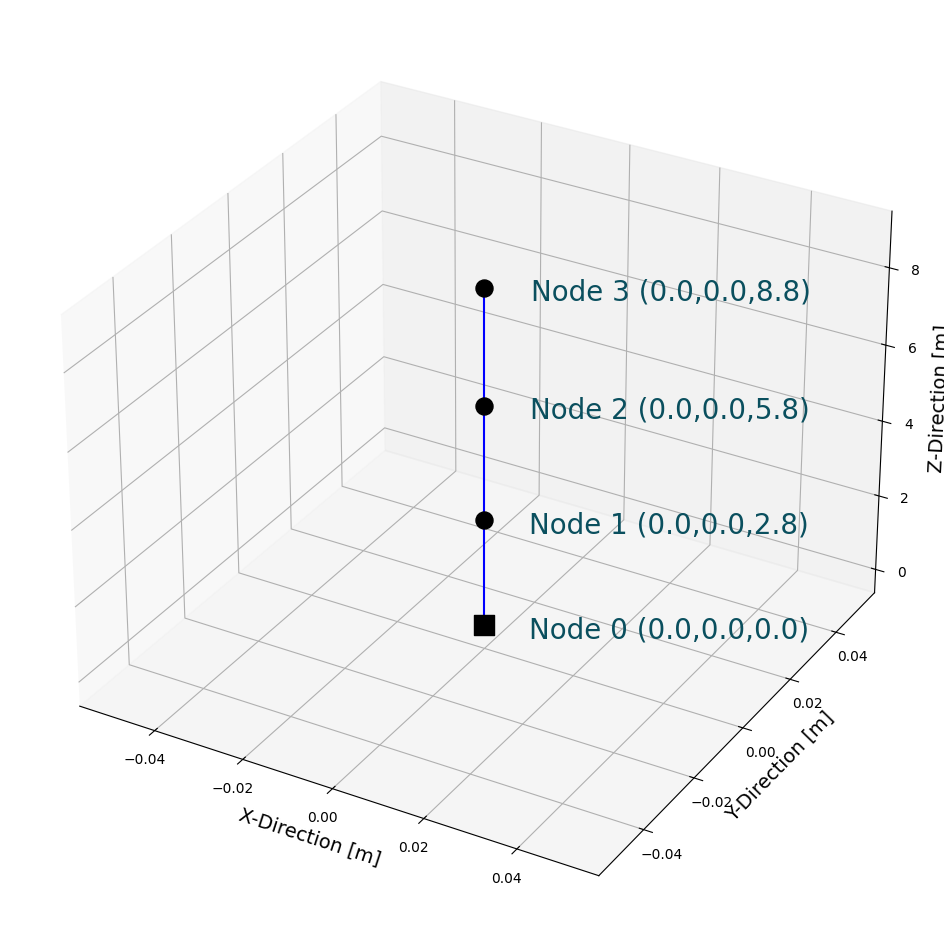

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Stopped because of load factor below zero

Saving animation to: out/spo_animation.gif


C:\Users\Moayad\Documents\GitHub\oq-vmtk\openquake\vmtk\plotter.py:800: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_model.set_xlim(model_x_lim)


ANALYSIS COMPLETED!


In [4]:
# Compile the MDOF model    
model = modeller(number_storeys,
                 floor_heights,
                 floor_masses,
                 storey_disps,
                 storey_forces*units.g,
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model    

# View the model
model.plot_model()                         # Visualise the model      

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes = number_storeys,
                                 plot_modes = False)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.005                 # Reference displacement
disp_scale_factor = 15           # Multiplier of the reference displacement
push_dir = 1                     # Push direction (for X-direction:1, for Y-direction=2)
phi = [0.33, 0.66, 1.00]         # Load pattern (In this example, we apply a user-defined triangular pattern)

# Do pushover analysis
results = model.do_spo_analysis(ref_disp, 
                                disp_scale_factor, 
                                push_dir, 
                                phi, 
                                pflag=False, 
                                num_steps=200, 
                                ansys_soe='BandGeneral', 
                                constraints_handler='Transformation', 
                                numberer='RCM', 
                                test_type='EnergyIncr', 
                                init_tol=1.0e-5, 
                                init_iter=1000, 
                                algorithm_type='KrylovNewton',
                                save_animation_path = 'out/spo_animation.gif') # Export animation of SPO when setting path, set to None if you opt not to

print('ANALYSIS COMPLETED!')

## Explore the Results of the Static Pushover Analysis ##

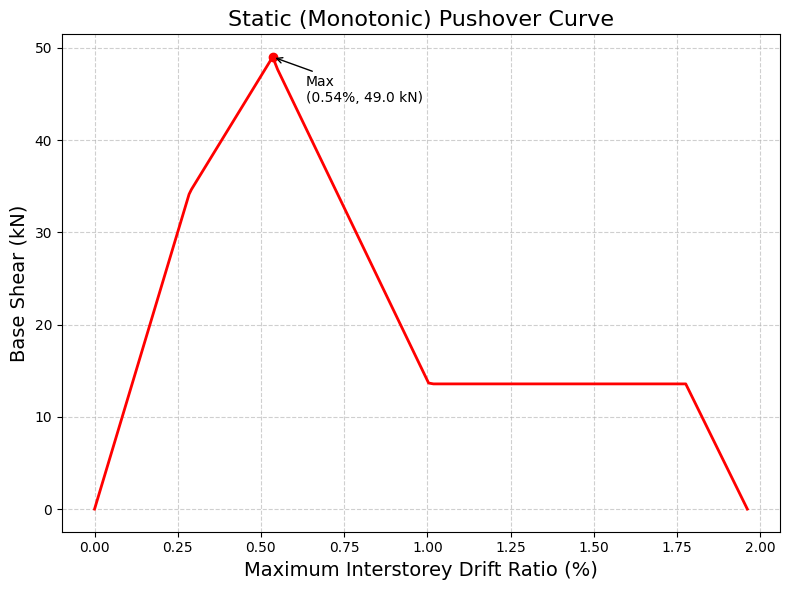

In [5]:
# Unpack the SPO results

spo_disps         = results['spo_disps']          # Displacements at each control node (i.e., floor)
spo_rxn           = results['spo_rxn']            # Reaction at base (Base shear)
spo_disps_spring  = results['spo_disps_spring']   # Displacements in nonlinear springs (i.e., zero-length elements)
spo_forces_spring = results['spo_forces_spring']  # Forces in nonlinear springs (i.e., zero-length elements)
spo_idr           = results['spo_idr']            # Interstorey drift ratios
spo_midr          = results['spo_midr']           # Maximum interstorey drifts

# Plot Static Pushover Results
plt.figure(figsize=(8, 6))
plt.plot(spo_midr, spo_rxn, linestyle='-', linewidth=LINEWIDTH_2, color = 'red', label = 'Static Pushover Curve')

# Add axis labels and title
plt.xlabel("Maximum Interstorey Drift Ratio (%)", fontsize=FONTSIZE_2)
plt.ylabel("Base Shear (kN)", fontsize=FONTSIZE_2)
plt.title("Static (Monotonic) Pushover Curve", fontsize=FONTSIZE_1)

# Annotate the peak point
max_idx = np.argmax(spo_rxn)
plt.plot(spo_midr[max_idx], spo_rxn[max_idx], 'ro')
plt.annotate(f'Max\n({spo_midr[max_idx]:.2f}%, {spo_rxn[max_idx]:.1f} kN)',
             xy=(spo_midr[max_idx], spo_rxn[max_idx]),
             xytext=(spo_midr[max_idx] + 0.1, spo_rxn[max_idx] * 0.9),
             arrowprops=dict(arrowstyle='->'))

# Add grid and show
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Setting Up, Running and Exporting Cyclic Pushover Analysis ##

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 3, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2002 has L= 3, which is greater than the tolerance


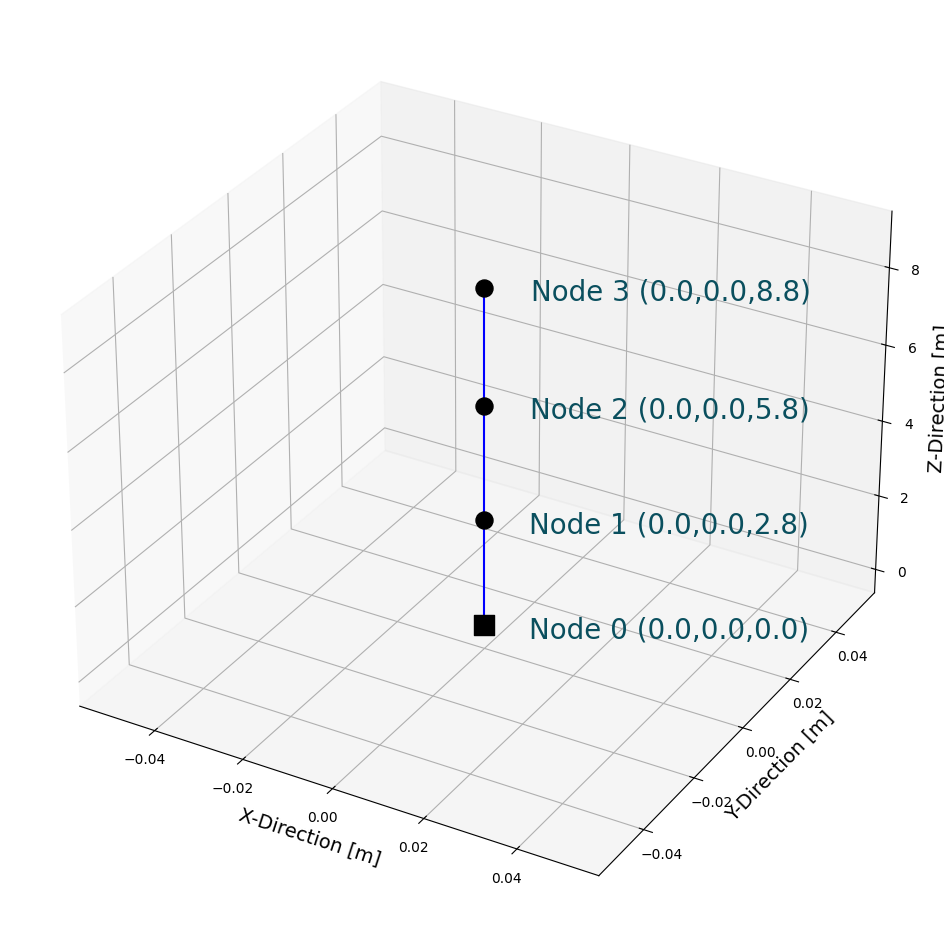

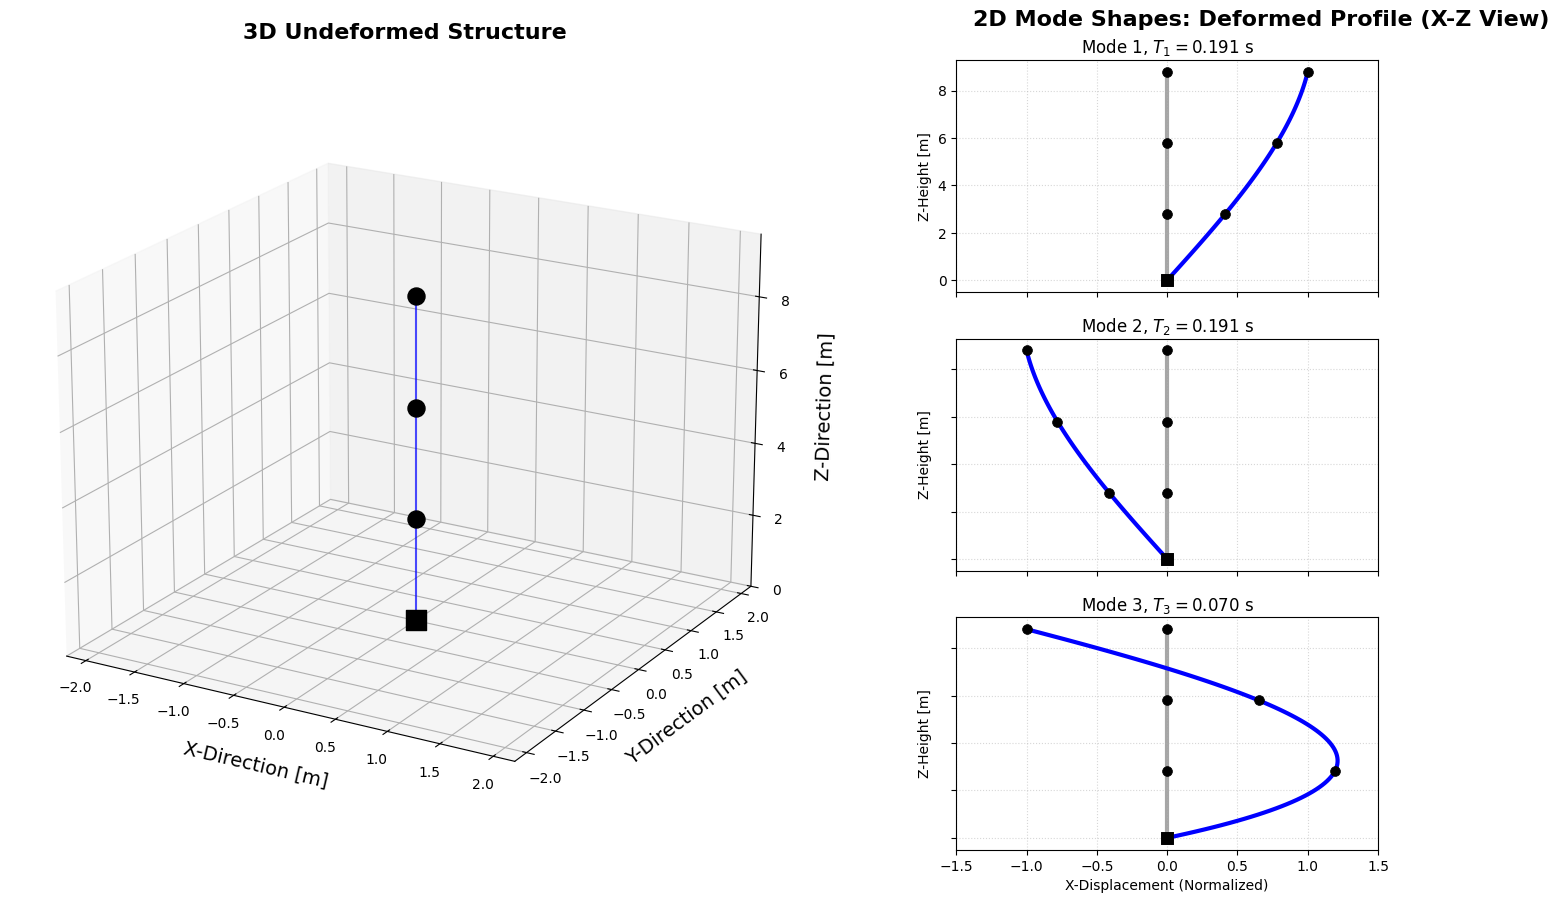

C:\Users\Moayad\Documents\GitHub\oq-vmtk\openquake\vmtk\plotter.py:1014: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax_model.set_xlim(model_x_lim)



Saving animation to: out/cpo_animation.gif
ANALYSIS COMPLETED!


In [6]:
# Compile the MDOF model    
model = modeller(number_storeys,
                 floor_heights,
                 floor_masses,
                 storey_disps,
                 storey_forces*units.g,
                 mdof_degradation)         # Initialise the class (Build the model)
model.compile_model()                      # Compile the MDOF model    

# View the model
model.plot_model()                         # Visualise the model      

# Do gravity analysis
model.do_gravity_analysis()                # Do gravity analysis

# Do modal analysis
T, phi = model.do_modal_analysis(num_modes = number_storeys)   # Do modal analysis and get period of vibration

# Define pushover analysis parameters
ref_disp = 0.001                               # Reference displacement
mu_levels = [1,2,4,6,8,10,12,15,20,25,30,50]   # Target ductility factor 
dispIncr = 5                                   # The number of displacement increments for each loading cycle
phi = [0.33, 0.66, 1.00]                       # Load pattern (In this example, we apply a user-defined triangular pattern)

# Do pushover analysis
results = model.do_cpo_analysis(ref_disp,
                                mu_levels, 
                                push_dir, 
                                dispIncr, 
                                phi,
                                pflag=False, 
                                ansys_soe='BandGeneral', 
                                constraints_handler='Transformation', 
                                numberer='RCM', 
                                test_type='NormDispIncr', 
                                init_tol=1.0e-5, 
                                init_iter=1000,
                                algorithm_type='KrylovNewton',
                                save_animation_path = 'out/cpo_animation.gif') # Export animation of CPO when setting path, set to None if you opt not to

print('ANALYSIS COMPLETED!')

## Explore the Results of the Cyclic Pushover Analysis ## 

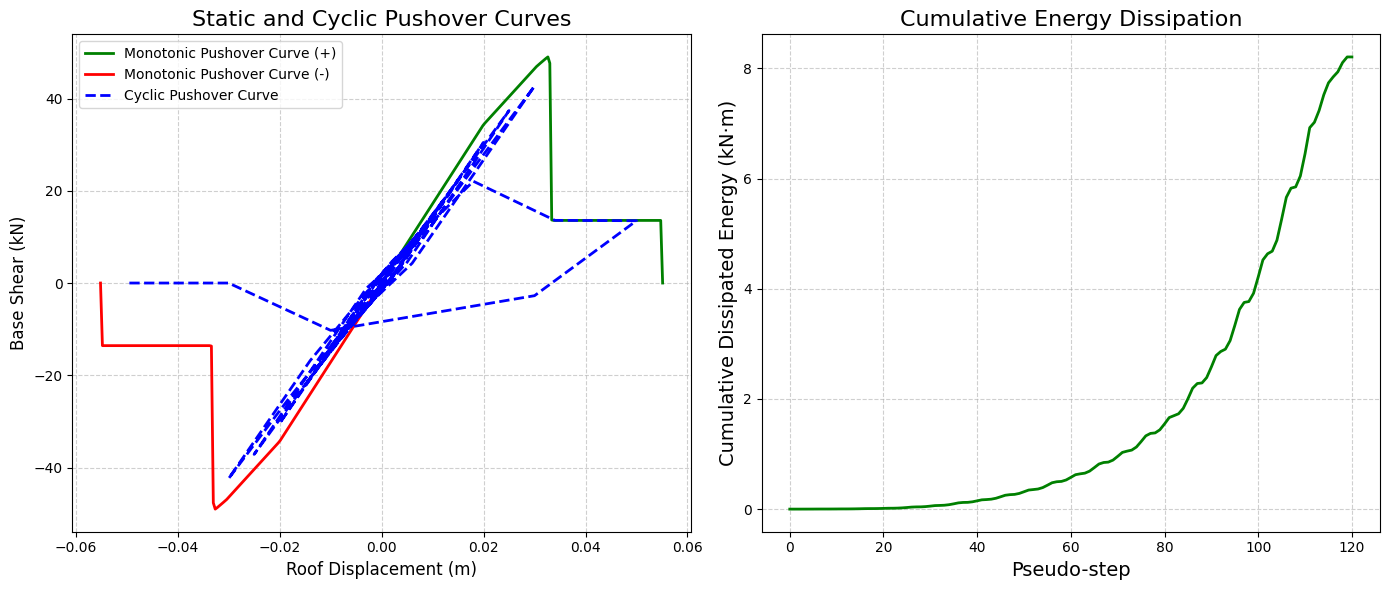

In [7]:
# Unpack results
cpo_disps  = results['cpo_disps']  # Displacements at each control node (i.e., floor)
cpo_rxn    = results['cpo_rxn']    # Reaction at base (Base shear)
cpo_energy = results['cpo_energy'] # Cumulative Dissipated Energy

roof_disp = cpo_disps[:, -1]  # Roof displacement time history

# Plot Cyclic Pushover Results with Monotonic Pushover Curve 
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Cyclic Pushover Curve
axs[0].plot(spo_disps[:, -1], spo_rxn, color='green', linewidth=LINEWIDTH_2,  label = 'Monotonic Pushover Curve (+)')
axs[0].plot(-spo_disps[:, -1],-spo_rxn, color='red', linewidth=LINEWIDTH_2, label = 'Monotonic Pushover Curve (-)')
axs[0].plot(roof_disp, cpo_rxn, color='blue', linewidth=LINEWIDTH_2, linestyle='--', label = 'Cyclic Pushover Curve')
axs[0].set_xlabel("Roof Displacement (m)", fontsize=12)
axs[0].set_ylabel("Base Shear (kN)", fontsize=12)
axs[0].set_title("Static and Cyclic Pushover Curves", fontsize=FONTSIZE_1)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Subplot 2: Cumulative Dissipated Energy
axs[1].plot(cpo_energy[:, 0], cpo_energy[:, 1], color='green', linewidth=LINEWIDTH_2)
axs[1].set_xlabel("Pseudo-step", fontsize=FONTSIZE_2)
axs[1].set_ylabel("Cumulative Dissipated Energy (kN·m)", fontsize=FONTSIZE_2)
axs[1].set_title("Cumulative Energy Dissipation", fontsize=FONTSIZE_1)
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()